# FINE TUNING BERT

In [ ]:
#Import Libraries
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import plotly.express as px

import seaborn as sns
import time
from IPython.display import clear_output

import nltk
from nltk.corpus import stopwords

import tensorflow as tf
import tensorflow_datasets as tfds

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification

# READING DATASET

In [ ]:
# loading dataset
df = pd.read_csv('Tweets.csv')
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='object')

# First ten records

In [ ]:
df.head(10)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


# LABEL CHECK

In [ ]:
df['airline_sentiment']

,airline_sentiment
0,neutral
1,positive
2,neutral
3,negative
4,negative
...,...
14635,positive
14636,negative
14637,neutral
14638,negative


# FEATURES/COLUMNS AND THEIR DATA TYPES

In [ ]:
print(f"{'COLUMN':<30} {'DATA TYPE':<20}")
print("-" * 40)

for col in df.columns:
    print(f"{col:<30} {str(df[col].dtype):<20}")

COLUMN                         DATA TYPE           
----------------------------------------
tweet_id                       int64               
airline_sentiment              object              
airline_sentiment_confidence   float64             
negativereason                 object              
negativereason_confidence      float64             
airline                        object              
airline_sentiment_gold         object              
name                           object              
negativereason_gold            object              
retweet_count                  int64               
text                           object              
tweet_coord                    object              
tweet_created                  object              
tweet_location                 object              
user_timezone                  object              


# DROPPING UNNECESSARY COLUMNS

We only need the text, actual tweet and sentiment which is our label, all other features are not required or useful for sentiment analysis purpose, that's why dropping them.

In [ ]:
df = df.drop(['tweet_id', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence',
              'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count',
              'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone'], axis=1)

In [ ]:
df.columns

Index(['airline_sentiment', 'text'], dtype='object')

# DATA PREPROCESSING

# Null Values Check

In [ ]:
df.isnull().sum()

,0
airline_sentiment,0
text,0


### MAPPING LABEL

- NEGATIVE -> 0
- NEUTRAL -> 1
- POSITIVE -> 2

In [ ]:
# Map sentiments to numerical labels
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['airline_sentiment'] = df['airline_sentiment'].map(sentiment_mapping)

### CHECKING CLASS BALANCE

In [ ]:
print(df['airline_sentiment'].value_counts())

airline_sentiment
0    9178
1    3099
2    2363
Name: count, dtype: int64


## To Lower Case

In [ ]:
# Lowercase
df['text'].str.lower()

,text
0,@virginamerica what @dhepburn said.
1,@virginamerica plus you've added commercials t...
2,@virginamerica i didn't today... must mean i n...
3,@virginamerica it's really aggressive to blast...
4,@virginamerica and it's a really big bad thing...
...,...
14635,@americanair thank you we got on a different f...
14636,@americanair leaving over 20 minutes late flig...
14637,@americanair please bring american airlines to...
14638,"@americanair you have my money, you change my ..."


# REMOVAL OF HTML TAGS

In [ ]:
import re
def remove_html_tags(text):
    return re.sub(r'<[^<]+?>', '', text)

df['text'] = df['text'].apply(remove_html_tags)

# REMOVAL OF URLS AND URL-CHARACTERS ETC.

In [ ]:
# remove URLs
def remove_url(text):
    return re.sub(r'http[s]?://\S+|www\.\S+', '', text)
df['text'] = df['text'].apply(remove_url)

# Special Character removal

In [ ]:
df['text']= df['text'].str.replace('[^a-zA-Z0-9\s]', '', regex=True)

In [ ]:
# Text preprocessing
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df['text'] = df['text'].apply(lambda x: ' '.join(word for word in x.split() if word not in stop_words))
df['text']=df['text'].str.lower()
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,airline_sentiment,text
0,1,virginamerica what dhepburn said
1,2,virginamerica plus youve added commercials exp...
2,1,virginamerica i didnt today must mean i need t...
3,0,virginamerica really aggressive blast obnoxiou...
4,0,virginamerica really big bad thing


In [ ]:
df.shape

(14640, 2)

In [ ]:
df['text'][5000]

'southwestair neveryamind i paid 450 flight 250 new bag easy business class customers right'

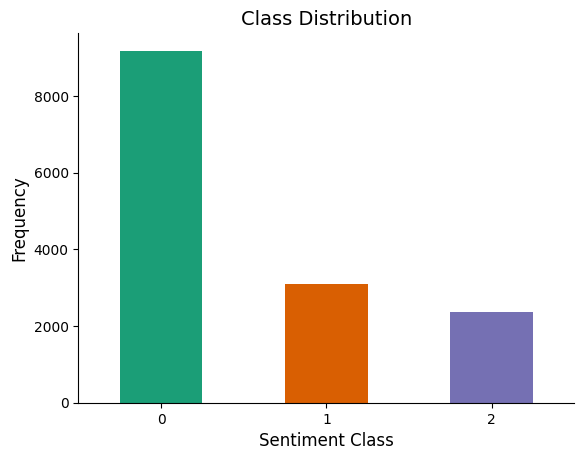

In [ ]:
def plot_class_distribution():
  df.groupby(['airline_sentiment']).size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'), rot=0)
  plt.title('Class Distribution', fontsize=14)
  plt.xlabel('Sentiment Class', fontsize=12)
  plt.ylabel('Frequency', fontsize=12)
  plt.gca().spines[['top', 'right']].set_visible(False)
  plt.show()

plot_class_distribution()

# Word Cloud

> It gives frequency of each word. Most frequent appears bigger in font size

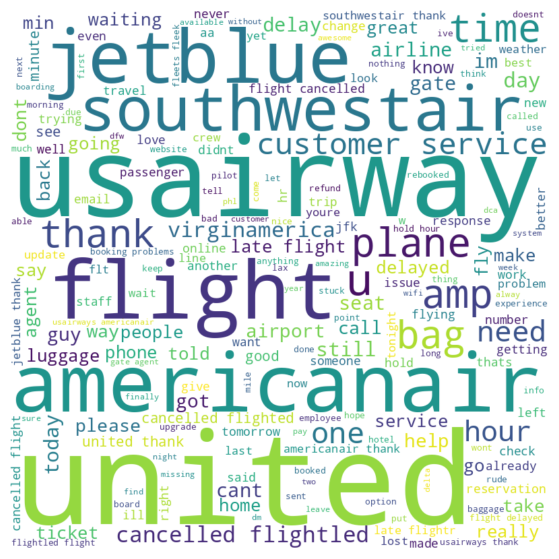

In [ ]:
from wordcloud import WordCloud
from collections import Counter

all_reviews = " ".join(df["text"])

wordcloud = WordCloud(width=800, height=800, background_color='white').generate(all_reviews)
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
df_transformed=df.copy()
df_transformed.to_csv('./data_transformed_tweets.csv', index=False)

# MODEL TRAINING

In [ ]:
from transformers import DistilBertModel

model_name = 'distilbert-base-uncased'
model = DistilBertModel.from_pretrained(model_name)

num_layers = len(model.transformer.layer)
print(f"\nNUMBER OF LAYERS {model_name}: {num_layers}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]


NUMBER OF LAYERS distilbert-base-uncased: 6


### Architecture of model before, locking layers

In [ ]:
print("Model Architecture:\n")
print(model)

Model Architecture:

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True

### Why Freeze the First 4 Layers?

1. **Keeps General Knowledge**: The first 4 layers handle basic language rules like grammar, which don't need retraining.

2. **Focus on Task**: The top 2 layers adjust to the sentiment analysis task.

3. **Avoid Overfitting**: Freezing most layers prevents the model from overfitting to the small dataset.

4. **Faster Training**: Fewer trainable layers mean quicker training.


In [ ]:
layers_to_freeze = 4

for i in range(layers_to_freeze):
    for param in model.transformer.layer[i].parameters():
        param.requires_grad = False

print(f"Locked the first {layers_to_freeze} layers for fine-tuning.")

print("\nTrainable Layers:")
for i, layer in enumerate(model.transformer.layer):
    trainable = any(param.requires_grad for param in layer.parameters())
    print(f"Layer {i}: {'Trainable' if trainable else 'Frozen'}")

print("\nModel Architecture:\n")
print(model)

Locked the first 4 layers for fine-tuning.

Trainable Layers:
Layer 0: Frozen
Layer 1: Frozen
Layer 2: Frozen
Layer 3: Frozen
Layer 4: Trainable
Layer 5: Trainable

Model Architecture:

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, e

In [ ]:
df=pd.read_csv("data_transformed_tweets.csv")
df.head()

,airline_sentiment,text
0,1,virginamerica what dhepburn said
1,2,virginamerica plus youve added commercials exp...
2,1,virginamerica i didnt today must mean i need t...
3,0,virginamerica really aggressive blast obnoxiou...
4,0,virginamerica really big bad thing


# SENTIMENT ANALYSIS USING DistillBERT

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### **Explanation of Steps:**

1. **Tokenization:**
   - Converts raw text into tokenized inputs (`input_ids` and `attention_mask`) compatible with the transformer model.
   - Handles padding, truncation, and adds special tokens like `[CLS]` and `[SEP]` to ensure uniform input size.

2. **Feature Mapping:**
   - Prepares tokenized inputs (`input_ids` and `attention_mask`) along with their corresponding labels in the format required for TensorFlow datasets.

3. **Dataset Encoding:**
   - Processes the entire dataset by tokenizing each example and organizing `input_ids`, `attention_mask`, and labels into lists.
   - Converts these lists into a TensorFlow dataset using `tf.data.Dataset.from_tensor_slices` and maps them into a structured format.


In [ ]:
def tokenize_review(review, tokenizer):
    encoded = tokenizer(
        text=review,
        add_special_tokens=True,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    return {
        "input_ids": encoded["input_ids"].numpy()[0],
        "attention_mask": encoded["attention_mask"].numpy()[0]
    }

# Dataset encoding function
def encode_dataset(dataset, tokenizer, limit=-1):
    input_ids_list = []
    attention_mask_list = []
    label_list = []

    if limit > 0:
        dataset = dataset.take(limit)

    for review, label in tfds.as_numpy(dataset):
        tokenized = tokenize_review(review.decode(), tokenizer)
        input_ids_list.append(tokenized['input_ids'])
        attention_mask_list.append(tokenized['attention_mask'])
        label_list.append(label)

    tf_dataset = tf.data.Dataset.from_tensor_slices((
        input_ids_list,
        attention_mask_list,
        label_list
    ))
    return tf_dataset.map(prepare_features)

def prepare_features(input_ids, attention_mask, label):
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }, label

# TRAIN/TEST SPLIT


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['airline_sentiment'], test_size=0.3, random_state=42)

# COMPUTING CLASS WEIGHTS

In [ ]:
# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Computed Class Weights: {class_weights_dict}")

Computed Class Weights: {0: 0.5367693274670019, 1: 1.5422121896162528, 2: 2.0467345715997602}


# HYPER PARAMETERS INITIALIZATION

In [ ]:
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
EPSILON = 1e-08

# Prepare dataset

In [ ]:
# Prepare TensorFlow datasets
ds_train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
ds_test = tf.data.Dataset.from_tensor_slices((X_test, y_test))

ds_train_encoded = encode_dataset(ds_train, tokenizer).shuffle(10000).batch(BATCH_SIZE)
ds_test_encoded = encode_dataset(ds_test, tokenizer).batch(BATCH_SIZE)

# Initialize and Compile the model

In [ ]:
model = TFDistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

optimizer = tf.optimizers.Adam(learning_rate=LEARNING_RATE, epsilon=EPSILON)
loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.metrics.SparseCategoricalAccuracy('accuracy')

model.compile(
    loss=loss,
    optimizer=optimizer,
    metrics=[metric]
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

# FINE TUNING



In [ ]:
import time
from datetime import datetime

for i in range(4):
    model.distilbert.transformer.layer[i].trainable = False

start_time = time.time()
readable_time = datetime.fromtimestamp(start_time).strftime('%Y-%m-%d %H:%M:%S')
print(f"STARTED AT: {readable_time}")

history = model.fit(
    ds_train_encoded,
    validation_data=ds_test_encoded,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

end_time = time.time()
readable_time = datetime.fromtimestamp(end_time).strftime('%Y-%m-%d %H:%M:%S')
print(f"ENDED AT = {end_time}")

STARTED AT: 2025-01-23 15:47:58
Epoch 1/3


ResourceExhaustedError: Graph execution error:

Detected at node tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._5/ffn/Gelu/mul_1 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 619, in start

  File "/usr/local/lib/python3.11/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/usr/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/usr/lib/python3.11/asyncio/events.py", line 84, in _run

  File "/usr/local/lib/python3.11/dist-packages/tornado/ioloop.py", line 685, 

# Performance evaluation

In [ ]:
save_path = '/sanple/five'
model.save_pretrained(save_path)

test_loss, test_accuracy = model.evaluate(ds_test_encoded)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

In [ ]:
# Predict on the test dataset
y_pred = []
y_true = []

for inputs, labels in ds_test_encoded:
    logits = model.predict(inputs).logits
    predictions = tf.argmax(logits, axis=-1)
    y_pred.extend(predictions.numpy())
    y_true.extend(labels.numpy())

# Classification Report

In [ ]:
# Generate a classification report
print(classification_report(y_true, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.89      0.86      0.87      2753
     Neutral       0.61      0.66      0.63       930
    Positive       0.72      0.73      0.72       709

    accuracy                           0.80      4392
   macro avg       0.74      0.75      0.74      4392
weighted avg       0.80      0.80      0.80      4392



275/275 [==============================] - 86s 306ms/step


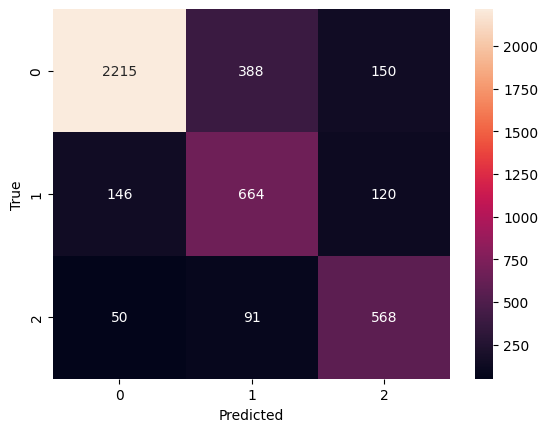

In [ ]:
predictions = model.predict(ds_test_encoded)
predicted_classes = np.argmax(predictions.logits, axis=1)
true_classes = y_test

# Confusion matrix
from sklearn.metrics import confusion_matrix

cm= confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# USING MODEL FOR SENTIMENT ANALYSIS

In [ ]:
from transformers import DistilBertTokenizer, TFDistilBertForSequenceClassification
import tensorflow as tf

model_path = '/content/drive/My Drive/MydistillBERT'
model = TFDistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Define sentiment mapping
sentiment_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}

# Function for sentiment analysis
def predict_sentiment(text):
    encoded = tokenizer(
        text,
        add_special_tokens=True,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="tf"
    )
    predictions = model.predict({
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask']
    }).logits
    predicted_label = tf.argmax(predictions, axis=1).numpy()[0]
    return sentiment_mapping[predicted_label]

while(True):
  user_input = input("Enter a sentence for sentiment analysis (q/e to exit): ")
  if user_input.lower() in ["q", "e", "exit", "quit"]:
    print("GOODBYE")
    break
  result = predict_sentiment(user_input)
  print(f"The sentiment is: {result}")

Some layers from the model checkpoint at /content/drive/My Drive/MydistillBERT were not used when initializing TFDistilBertForSequenceClassification: ['dropout_39']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at /content/drive/My Drive/MydistillBERT and are newly initialized: ['dropout_79']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Enter a sentence for sentiment analysis (q/e to exit): What are you doing?
1/1 [==============================] - 1s 1s/step
The sentiment is: Negative
Enter a sentence for sentiment analysis (q/e to exit): Why are you here?
1/1 [==============================] - 0s 53ms/step
The sentiment is: Negative
Enter a sentence for sentiment analysis (q/e to exit): Lets Go
1/1 [==============================] - 0s 67ms/step
The sentiment is: Positive
Enter a sentence for sentiment analysis (q/e to exit): The flight was good bad
1/1 [==============================] - 0s 57ms/step
The sentiment is: Negative
Enter a sentence for sentiment analysis (q/e to exit): good
1/1 [==============================] - 0s 52ms/step
The sentiment is: Neutral
Enter a sentence for sentiment analysis (q/e to exit): bad
1/1 [==============================] - 0s 58ms/step
The sentiment is: Neutral
Enter a sentence for sentiment analysis (q/e to exit): worst
1/1 [==============================] - 0s 68ms/step
The sent

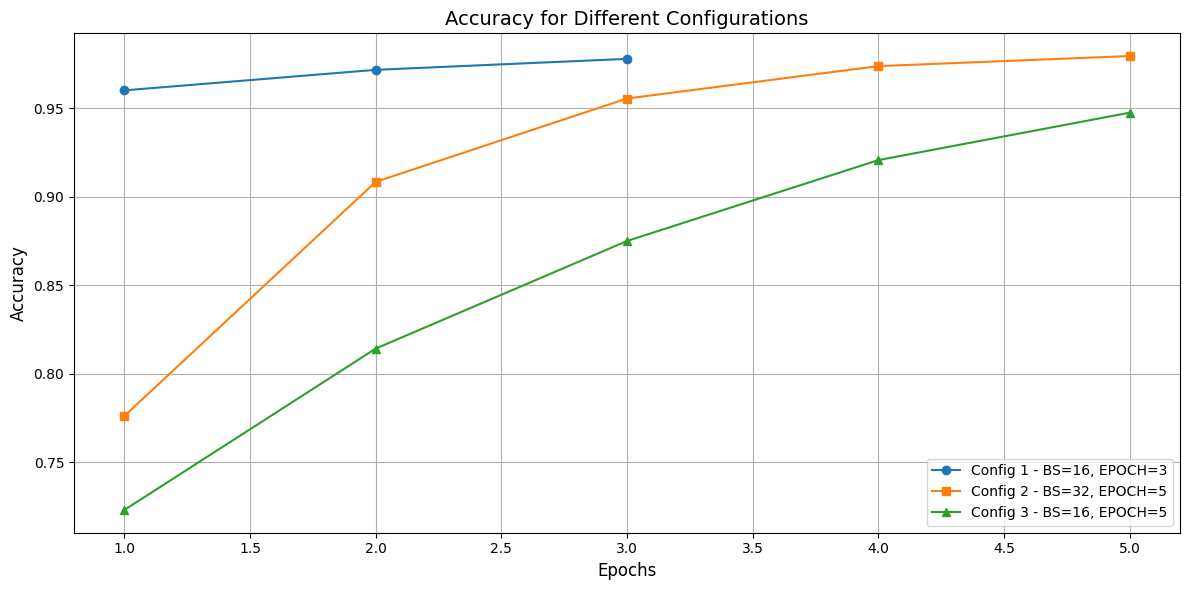

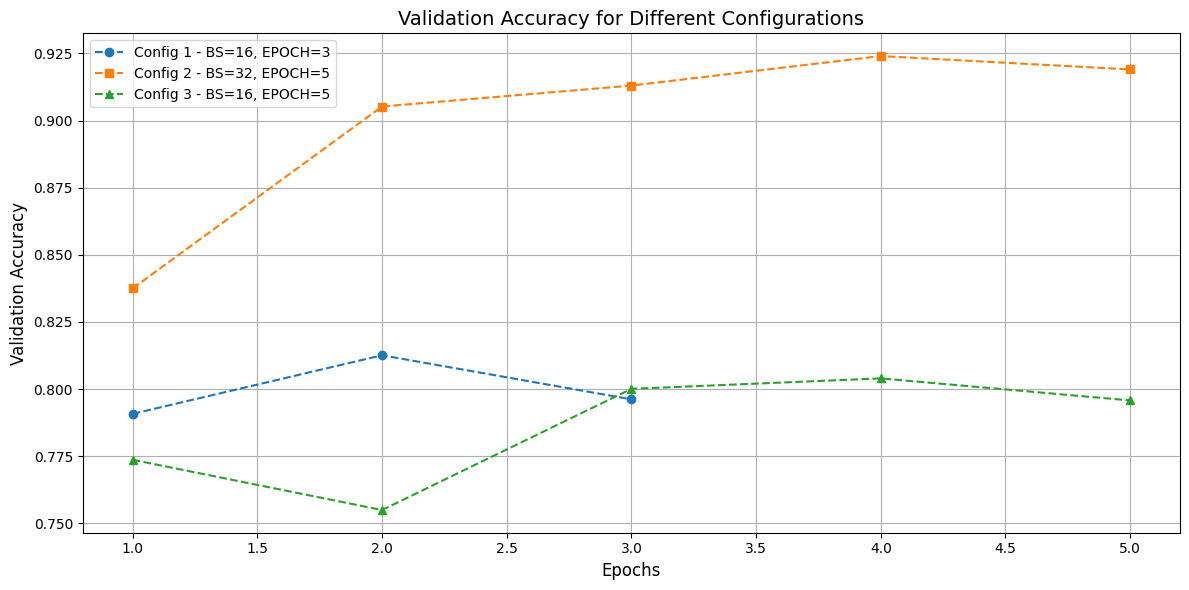

In [ ]:
import matplotlib.pyplot as plt

# Data for plotting
epochs_3 = [1, 2, 3]
epochs_5 = [1, 2, 3, 4, 5]

# Configurations data
config1_acc = [0.9602, 0.9718, 0.9780]
config1_val_acc = [0.7908, 0.8126, 0.7962]

config2_acc = [0.7762, 0.9085, 0.9556, 0.9739, 0.9796]
config2_val_acc = [0.8375, 0.9052, 0.9130, 0.9240, 0.9190]

config3_acc = [0.7231, 0.8143, 0.8751, 0.9208, 0.9476]
config3_val_acc = [0.7737, 0.7550, 0.8001, 0.8040, 0.7958]

# Plotting Accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs_3, config1_acc, marker='o', label='Config 1 - BS=16, EPOCH=3')
plt.plot(epochs_5, config2_acc, marker='s', label='Config 2 - BS=32, EPOCH=5')
plt.plot(epochs_5, config3_acc, marker='^', label='Config 3 - BS=16, EPOCH=5')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy for Different Configurations', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n\n\n\n")

# Plotting Validation Accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs_3, config1_val_acc, marker='o', linestyle='--', label='Config 1 - BS=16, EPOCH=3')
plt.plot(epochs_5, config2_val_acc, marker='s', linestyle='--', label='Config 2 - BS=32, EPOCH=5')
plt.plot(epochs_5, config3_val_acc, marker='^', linestyle='--', label='Config 3 - BS=16, EPOCH=5')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Validation Accuracy for Different Configurations', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from datasets import load_dataset
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)
print(f"Accuracy: {accuracy * 100:.2f}%")


Accuracy: 51.85%
